In [6]:
print("Earthquake Project Started")

Earthquake Project Started


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex
import streamlit
import sqlalchemy
import requests
from datetime import datetime
import os
print("All libraries are working!")

All libraries are working!


#DATA RETRIVAL

In [8]:
#adding url
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

In [9]:
#created empty list anb setting the start and end year
all_records = []
start_year = datetime.now().year -5
end_year = datetime.now().year

In [10]:
for year in range(start_year, end_year + 1):

    for month in range(1, 13):

        start_date = f'{year}-{month:02d}-01'

        if month == 12:
            end_date = f'{year+1}-01-01'
        else:
            end_date = f'{year}-{month+1:02d}-01'

        params = {
            'format': 'geojson',
            'starttime': start_date,
            'endtime': end_date,
            'minmagnitude': 3
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f'failed for {start_date}')
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f'json error for {start_date}: {e}')
            continue

        for f in data['features']:

            p = f['properties']
            g = f['geometry']['coordinates']

            all_records.append({
                'id': f.get('id'),
                'time': pd.to_datetime(p.get('time'), unit='ms'),
                'updated': pd.to_datetime(p.get('updated'), unit='ms'),
                'latitude': g[1] if g else None,
                'longitude': g[0] if g else None,
                'depth_km': g[2] if g else None,
                'mag': p.get('mag'),
                'magType': p.get('magType'),
                'place': p.get('place'),
                'status': p.get('status'),
                'tsunami': p.get('tsunami'),
                'sig': p.get('sig'),
                'net': p.get('net'),
                'nst': p.get('nst'),
                'dmin': p.get('dmin'),
                'rms': p.get('rms'),
                'gap': p.get('gap'),
                'types': p.get('types'),
                'ids': p.get('ids'),
                'sources': p.get('sources'),
                'type': p.get('type'),
                'magSource': p.get('magSource'),
                'locationSource': p.get('locationSource'),
                'magNst': p.get('magNst'),
                'depthError': p.get('depthError'),
                'magError': p.get('magError')
            })   

In [74]:
#added the retrived records in empty list
df = pd.DataFrame(all_records)


In [75]:
df.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type', 'magSource',
       'locationSource', 'magNst', 'depthError', 'magError'],
      dtype='object')

In [76]:
#checking row, columns and start, end time to make sure data imported correctly
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Minimum date:", df["time"].min())
print("Maximum date:", df["time"].max())

Rows: 117667
Columns: 26
Minimum date: 2021-01-01 00:14:07.580000
Maximum date: 2026-08-19 04:22:54.144000


In [77]:
df['time'].dt.month.value_counts().sort_index()

time
1     10579
2     10065
3     10931
4     10331
5      9763
6      9556
7     11696
8     10656
9      8316
10     8145
11     7954
12     9675
Name: count, dtype: int64

In [78]:
#checking null values
df.isna().sum()

id                     0
time                   0
updated                0
latitude               0
longitude              0
depth_km               0
mag                    0
magType                0
place                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                27762
dmin                3977
rms                   19
gap                 3022
types                  0
ids                    0
sources                0
type                   0
magSource         117667
locationSource    117667
magNst            117667
depthError        117667
magError          117667
dtype: int64

In [79]:
df.describe()

,time,updated,latitude,longitude,depth_km,mag,tsunami,sig,nst,dmin,rms,gap
count,117667,117667,117667.000000,117667.000000,117667.000000,117667.000000,117667.000000,117667.000000,89905.000000,113690.000000,117648.000000,114645.000000
mean,2023-10-26 17:41:06.537221632,2024-02-12 03:08:17.447950592,12.225048,7.819440,71.582425,4.255880,0.005601,287.488319,45.471898,3.189264,0.659098,122.747227
min,2021-01-01 00:14:07.580000,2021-01-01 10:15:32.601000,-84.493200,-179.999700,-3.740000,3.000000,0.000000,138.000000,0.000000,0.000000,0.000000,8.000000
25%,2022-05-09 07:35:33.577499904,2022-08-28 03:21:13.040000,-14.219800,-112.026133,10.000000,4.000000,0.000000,246.000000,20.000000,0.835000,0.490000,75.000000
50%,2023-11-03 23:31:52.209999872,2024-02-10 23:47:38.040000,14.893700,25.233800,21.483000,4.300000,0.000000,284.000000,32.000000,1.814000,0.650000,113.000000
75%,2025-04-27 23:45:47.103500032,2025-08-22 20:26:04.040000,39.166350,130.571900,70.771000,4.600000,0.000000,326.000000,56.000000,3.726000,0.820000,157.000000
max,2026-08-19 04:22:54.144000,2026-08-19 05:09:54.547000,87.375200,179.999400,683.578000,8.800000,1.000000,2910.000000,619.000000,62.558000,3.400000,359.000000
std,NaN,NaN,31.949652,129.036150,122.940665,0.611104,0.074627,92.043551,39.490784,4.458178,0.259166,62.925453


In [80]:
#checking dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117667 entries, 0 to 117666
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              117667 non-null  object        
 1   time            117667 non-null  datetime64[ns]
 2   updated         117667 non-null  datetime64[ns]
 3   latitude        117667 non-null  float64       
 4   longitude       117667 non-null  float64       
 5   depth_km        117667 non-null  float64       
 6   mag             117667 non-null  float64       
 7   magType         117667 non-null  object        
 8   place           117667 non-null  object        
 9   status          117667 non-null  object        
 10  tsunami         117667 non-null  int64         
 11  sig             117667 non-null  int64         
 12  net             117667 non-null  object        
 13  nst             89905 non-null   float64       
 14  dmin            113690 non-null  flo

In [81]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

CLEANING DATA

In [82]:
#creating new datafarme to clean the data 
df_new = df.copy()

In [83]:
print('cleaned: ',df_new.shape)
print('raw: ', df.shape)

cleaned:  (117667, 26)
raw:  (117667, 26)


In [84]:
df_new['time'].dt.month.value_counts().sort_index()

time
1     10579
2     10065
3     10931
4     10331
5      9763
6      9556
7     11696
8     10656
9      8316
10     8145
11     7954
12     9675
Name: count, dtype: int64

In [85]:
df_new['time'].dt.year.value_counts().sort_index()

time
2021    21926
2022    20208
2023    20830
2024    18659
2025    22818
2026    13226
Name: count, dtype: int64

In [86]:
#checking null values 
df_new.isna().sum()

id                     0
time                   0
updated                0
latitude               0
longitude              0
depth_km               0
mag                    0
magType                0
place                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                27762
dmin                3977
rms                   19
gap                 3022
types                  0
ids                    0
sources                0
type                   0
magSource         117667
locationSource    117667
magNst            117667
depthError        117667
magError          117667
dtype: int64

In [87]:
#DROPPING THE EMPTY COLUMNS BECAUSE THEY WHERE 100% MISSING IN OUR COLLECTED API DATA
empty_columns = [
    'magSource',
    'locationSource',
    'magNst',
    'depthError',
    'magError'
]
df_new =  df_new.drop(columns= empty_columns)

In [88]:
df_new.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type'],
      dtype='object')

In [89]:
#ckecking the remaining columns count 
print('orignal_columns:',df.shape[1])
print('new_columns:',df_new.shape[1])

orignal_columns: 26
new_columns: 21


In [27]:
#CHECKING MISSING VALUES 
df_new.isnull().sum()

id               0
time             0
updated          0
latitude         0
longitude        0
depth_km         0
mag              0
magType          0
place            0
status           0
tsunami          0
sig              0
net              0
nst          27762
dmin          3977
rms             19
gap           3022
types            0
ids              0
sources          0
type             0
dtype: int64

#HANDLING THE MISSING COLUMNS WHICH HAS MISSING VALUES

In [28]:
#NST
df_new['nst'].dtype
df_new['nst'].describe()
df_new['nst'].isnull().sum()
print('DATA TYPES:' , df_new["nst"].dtype)
print('DESCRIBE :l' , df_new["nst"].describe())
print('MISSING VALUES:' , df_new["nst"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    89905.000000
mean        45.471898
std         39.490784
min          0.000000
25%         20.000000
50%         32.000000
75%         56.000000
max        619.000000
Name: nst, dtype: float64
MISSING VALUES: 27762


In [29]:
#checking outliers
Q1 = df_new["nst"].quantile(0.25)
Q3 = df_new["nst"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 20.0
Q3: 56.0
IQR: 36.0
Lower limit: -34.0
Upper limit: 110.0


In [30]:
#found outliers 
df_new[df_new["nst"] < lower].shape[0]
df_new[df_new["nst"] > upper].shape[0]
print('LOWER:' , df_new[df_new["nst"] < lower].shape[0])
print('UPPER:', df_new[df_new["nst"] > upper].shape[0])


LOWER: 0
UPPER: 6165


In [31]:
#filling values using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['nst'].median())
df_new["nst"] = df_new["nst"].fillna(df_new["nst"].median())

MEDIAN: 32.0


In [32]:
df_new['nst'].isna().sum()

np.int64(0)

In [33]:
#dmin
df_new['dmin'].dtype
df_new['dmin'].describe()
df_new['dmin'].isnull().sum()
print('DATA TYPES:' , df_new["dmin"].dtype)
print('DESCRIBE :l' , df_new["dmin"].describe())
print('MISSING VALUES:' , df_new["dmin"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    113690.000000
mean          3.189264
std           4.458178
min           0.000000
25%           0.835000
50%           1.814000
75%           3.726000
max          62.558000
Name: dmin, dtype: float64
MISSING VALUES: 3977


In [34]:
#checking outliers
Q1 = df_new["dmin"].quantile(0.25)
Q3 = df_new["dmin"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.835
Q3: 3.726
IQR: 2.891
Lower limit: -3.5015
Upper limit: 8.0625


In [35]:
#found outliers 
df_new[df_new["dmin"] < lower].shape[0]
df_new[df_new["dmin"] > upper].shape[0]
print('LOWER:' , df_new[df_new["dmin"] < lower].shape[0])
print('UPPER:', df_new[df_new["dmin"] > upper].shape[0])

LOWER: 0
UPPER: 8393


In [36]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['dmin'].median())
df_new["dmin"] = df_new["dmin"].fillna(df_new["dmin"].median())

MEDIAN: 1.814


In [37]:
df_new['dmin'].isna().sum()

np.int64(0)

In [38]:
#rms
df_new['rms'].dtype
df_new['rms'].describe()
df_new['rms'].isnull().sum()
print('DATA TYPES:' , df_new["rms"].dtype)
print('DESCRIBE :l' , df_new["rms"].describe())
print('MISSING VALUES:' , df_new["rms"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    117648.000000
mean          0.659098
std           0.259166
min           0.000000
25%           0.490000
50%           0.650000
75%           0.820000
max           3.400000
Name: rms, dtype: float64
MISSING VALUES: 19


In [39]:
#checking outliers by using IQR
Q1 = df_new["rms"].quantile(0.25)
Q3 = df_new["rms"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.49
Q3: 0.82
IQR: 0.32999999999999996
Lower limit: -0.004999999999999949
Upper limit: 1.315


In [40]:
#found outliers 
df_new[df_new["rms"] < lower].shape[0]
df_new[df_new["rms"] > upper].shape[0]
print('LOWER:' , df_new[df_new["rms"] < lower].shape[0])
print('UPPER:', df_new[df_new["rms"] > upper].shape[0])

LOWER: 0
UPPER: 800


In [41]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['rms'].median())
df_new["rms"] = df_new["rms"].fillna(df_new["rms"].median())

MEDIAN: 0.65


In [42]:
df_new['rms'].isna().sum()

np.int64(0)

In [43]:
#gap
df_new['gap'].dtype
df_new['gap'].describe()
df_new['gap'].isnull().sum()
print('DATA TYPES:' , df_new["gap"].dtype)
print('DESCRIBE :l' , df_new["gap"].describe())
print('MISSING VALUES:' , df_new["gap"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    114645.000000
mean        122.747227
std          62.925453
min           8.000000
25%          75.000000
50%         113.000000
75%         157.000000
max         359.000000
Name: gap, dtype: float64
MISSING VALUES: 3022


In [44]:
#checking outliers by using IQR
Q1 = df_new["gap"].quantile(0.25)
Q3 = df_new["gap"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 75.0
Q3: 157.0
IQR: 82.0
Lower limit: -48.0
Upper limit: 280.0


In [90]:
#found outliers 
df_new[df_new["gap"] < lower].shape[0]
df_new[df_new["gap"] > upper].shape[0]
print('LOWER:' , df_new[df_new["gap"] < lower].shape[0])
print('UPPER:', df_new[df_new["gap"] > upper].shape[0])

LOWER: 0
UPPER: 2654


In [46]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['gap'].median())
df_new["gap"] = df_new["gap"].fillna(df_new["gap"].median())

MEDIAN: 113.0


In [47]:
df_new['gap'].isna().sum()

np.int64(0)

In [48]:
df_new.isnull().sum()

id           0
time         0
updated      0
latitude     0
longitude    0
depth_km     0
mag          0
magType      0
place        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         0
rms          0
gap          0
types        0
ids          0
sources      0
type         0
dtype: int64

#VALIDATING EACH COLUMN 

In [49]:
#Latitude
print('Empty:', df_new['latitude'].isna().sum())
print("Min:", df_new["latitude"].min())
print("Max:", df_new["latitude"].max())

print("Invalid latitude:",
      ((df_new["latitude"] < -90) | (df_new["latitude"] > 90)).sum())

Empty: 0
Min: -84.4932
Max: 87.3752
Invalid latitude: 0


In [50]:
#Longitude 
print('Empty:', df_new['longitude'].isna().sum())
print("Min:" , df_new["longitude"].min())
print("Max:", df_new["longitude"].max())
print("Invalid Longitude:", ((df_new["longitude"] < -180) | (df_new["longitude"] > 180)).sum())

Empty: 0
Min: -179.9997
Max: 179.9994
Invalid Longitude: 0


In [51]:
#depth_km
print('Empty:', df_new['depth_km'].isna().sum())
df_new['depth_km'].describe()
print("Min:" , df_new["depth_km"].min())
print("Max:", df_new["depth_km"].max())
print("Negative depth:", (df_new["depth_km"] < 0).sum())

Empty: 0
Min: -3.74
Max: 683.578
Negative depth: 115


In [52]:
#mag
print('Empty:', df_new['mag'].isna().sum())
print(df_new['mag'].describe())
print('Empty:', df_new['mag'].isna().sum())
print("Min:" , df_new["mag"].min())
print("Max:", df_new["mag"].max())

Empty: 0
count    117667.000000
mean          4.255880
std           0.611104
min           3.000000
25%           4.000000
50%           4.300000
75%           4.600000
max           8.800000
Name: mag, dtype: float64
Empty: 0
Min: 3.0
Max: 8.8


In [53]:
#nst
print('Empty:', df_new['nst'].isna().sum())
print(df_new["nst"].describe())
print("Negative NST:",(df_new["nst"] < 0).sum())
print("Zero NST:",(df_new["nst"] == 0).sum())

Empty: 0
count    117667.000000
mean         42.293379
std          34.989826
min           0.000000
25%          23.000000
50%          32.000000
75%          46.000000
max         619.000000
Name: nst, dtype: float64
Negative NST: 0
Zero NST: 6


In [54]:
#dmin
print('Empty:', df_new['dmin'].isna().sum())
print(df_new["dmin"].describe())
print("Negative dmin:", (df_new["dmin"] < 0).sum())

Empty: 0
count    117667.000000
mean          3.142782
std           4.389231
min           0.000000
25%           0.864000
50%           1.814000
75%           3.617500
max          62.558000
Name: dmin, dtype: float64
Negative dmin: 0


In [55]:
#gap
print('Empty:', df_new['gap'].isna().sum())
print(df_new["gap"].describe())
print("Negative gap:",(df_new["gap"] < 0).sum())

Empty: 0
count    117667.000000
mean        122.496892
std          62.131279
min           8.000000
25%          76.000000
50%         113.000000
75%         155.000000
max         359.000000
Name: gap, dtype: float64
Negative gap: 0


In [56]:
#sig
print('Empty:', df_new['sig'].isna().sum())
print(df_new["sig"].describe())
print("Negative sig:", (df_new["sig"] < 0).sum())

Empty: 0
count    117667.000000
mean        287.488319
std          92.043551
min         138.000000
25%         246.000000
50%         284.000000
75%         326.000000
max        2910.000000
Name: sig, dtype: float64
Negative sig: 0


In [57]:
#tsunami
print('Empty:', df_new['tsunami'].isna().sum())
print(df_new["tsunami"].value_counts())

Empty: 0
tsunami
0    117008
1       659
Name: count, dtype: int64


In [58]:
#status
print('Empty:', df_new['status'].isna().sum())
print(df_new["status"].value_counts())

Empty: 0
status
reviewed     117499
automatic       168
Name: count, dtype: int64


In [59]:
#type
print('Empty:', df_new['type'].isna().sum())
print(df_new["type"].value_counts(dropna=False))

Empty: 0
type
earthquake                116772
mining explosion             850
ice quake                     13
volcanic eruption             12
experimental explosion         5
other event                    5
mine collapse                  3
landslide                      3
quarry blast                   2
Landslide                      1
explosion                      1
Name: count, dtype: int64


In [60]:
#magType
print('Empty:', df_new['magType'].isna().sum())
print(df_new["magType"].value_counts())

Empty: 0
magType
mb            83339
ml            16958
mww            7258
md             6443
mwr            2777
mw              670
mb_lg           125
ml(texnet)       43
mwb              31
mlr              10
mlv               5
mwc               2
ms_vx             2
ms_20             1
mlg               1
mwp               1
mh                1
Name: count, dtype: int64


In [61]:
#Date columns
print('Empty:', df_new['time'].isna().sum())
print(df_new["time"].dtype)
print(df_new["updated"].dtype)

print("Time range:")
print(df_new["time"].min())
print(df_new["time"].max())

print("Updated before event:",  (df_new["updated"] < df_new["time"]).sum())

Empty: 0
datetime64[ns]
datetime64[ns]
Time range:
2021-01-01 00:14:07.580000
2026-08-19 04:22:54.144000
Updated before event: 0


In [62]:
#id
print('Empty:', df_new['id'].isna().sum())
print('ID is unique:' , df_new["id"].is_unique)



Empty: 0
ID is unique: True


In [63]:
#net
print('Empty:', df_new['net'].isna().sum())
print(df_new["net"].value_counts())


Empty: 0
net
us        102831
pr          6425
ak          3792
tx          1018
nc           992
hv           930
ci           901
nn           456
uu           109
ok            92
uw            57
nm            22
se            18
iscgem        16
av             5
ew             2
mb             1
Name: count, dtype: int64


In [64]:
#place
print('Empty:', df_new['place'].isna().sum())
print(df_new["place"].head(20))




Empty: 0
0           29 km SW of Villa Basilio Nievas, Argentina
1                                           Fiji region
2                       103 km SW of Basco, Philippines
3                               114 km N of M?n?b, Iran
4     184 km ENE of Olonkinbyen, Svalbard and Jan Mayen
5                    76 km NNE of Luquillo, Puerto Rico
6                    78 km NNE of Luquillo, Puerto Rico
7                       82 km N of Culebra, Puerto Rico
8                  99 km SE of Pondaguitan, Philippines
9                  69 km SE of Pondaguitan, Philippines
10                   75 km NNE of Luquillo, Puerto Rico
11                   76 km NNE of Luquillo, Puerto Rico
12                          52 km NE of Yairipok, India
13                  198 km SE of Sarangani, Philippines
14                          82 km SSE of Lethem, Guyana
15                         23 km ESE of Wright, Wyoming
16                   76 km NNE of Luquillo, Puerto Rico
17                   72 km NNE of Luqui

In [65]:

#types
print('Empty:', df_new['types'].isna().sum())
print(df_new["types"].head())


Empty: 0
0    ,dyfi,moment-tensor,origin,phase-data,
1                       ,origin,phase-data,
2                       ,origin,phase-data,
3                       ,origin,phase-data,
4                       ,origin,phase-data,
Name: types, dtype: object


In [66]:
#ids
print('Empty:', df_new['ids'].isna().sum())
print(df_new["ids"].head())


Empty: 0
0    ,us6000ddi8,
1    ,us6000dev6,
2    ,us6000dev5,
3    ,us6000ddhs,
4    ,us6000dev4,
Name: ids, dtype: object


In [67]:
#sources
print('Empty:', df_new['sources'].isna().sum())
print(df_new["sources"].head())

Empty: 0
0    ,us,
1    ,us,
2    ,us,
3    ,us,
4    ,us,
Name: sources, dtype: object


CHECKING THE ENTIRE DATA AFTER DATA CLEANING

In [68]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])

print("\nDuplicate rows:")
print(df_new.duplicated().sum())

print("\nMissing values:")
print(df_new.isnull().sum())


print("\nData types:")
print(df_new.dtypes)

Rows: 117667
Columns: 21

Duplicate rows:
0

Missing values:
id           0
time         0
updated      0
latitude     0
longitude    0
depth_km     0
mag          0
magType      0
place        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         0
rms          0
gap          0
types        0
ids          0
sources      0
type         0
dtype: int64

Data types:
id                   object
time         datetime64[ns]
updated      datetime64[ns]
latitude            float64
longitude           float64
depth_km            float64
mag                 float64
magType              object
place                object
status               object
tsunami               int64
sig                   int64
net                  object
nst                 float64
dmin                float64
rms                 float64
gap                 float64
types                object
ids                  object
sources              object
type                 object
dtype: obj

In [69]:
df_new.describe(include="all")

,id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,...,sig,net,nst,dmin,rms,gap,types,ids,sources,type
count,117667,117667,117667,117667.000000,117667.000000,117667.000000,117667.000000,117667,117667,117667,...,117667.000000,117667,117667.000000,117667.000000,117667.000000,117667.000000,117667,117667,117667,117667
unique,117667,NaN,NaN,NaN,NaN,NaN,NaN,17,64722,2,...,NaN,17,NaN,NaN,NaN,NaN,575,117667,375,11
top,us6000ddi8,NaN,NaN,NaN,NaN,NaN,NaN,mb,South Sandwich Islands region,reviewed,...,NaN,us,NaN,NaN,NaN,NaN,",origin,phase-data,",",us6000ddi8,",",us,",earthquake
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,83339,3180,117499,...,NaN,102831,NaN,NaN,NaN,NaN,89475,1,85632,116772
mean,NaN,2023-10-26 17:41:06.537221632,2024-02-12 03:08:17.447950592,12.225048,7.819440,71.582425,4.255880,NaN,NaN,NaN,...,287.488319,NaN,42.293379,3.142782,0.659096,122.496892,NaN,NaN,NaN,NaN
min,NaN,2021-01-01 00:14:07.580000,2021-01-01 10:15:32.601000,-84.493200,-179.999700,-3.740000,3.000000,NaN,NaN,NaN,...,138.000000,NaN,0.000000,0.000000,0.000000,8.000000,NaN,NaN,NaN,NaN
25%,NaN,2022-05-09 07:35:33.577499904,2022-08-28 03:21:13.040000,-14.219800,-112.026133,10.000000,4.000000,NaN,NaN,NaN,...,246.000000,NaN,23.000000,0.864000,0.490000,76.000000,NaN,NaN,NaN,NaN
50%,NaN,2023-11-03 23:31:52.209999872,2024-02-10 23:47:38.040000,14.893700,25.233800,21.483000,4.300000,NaN,NaN,NaN,...,284.000000,NaN,32.000000,1.814000,0.650000,113.000000,NaN,NaN,NaN,NaN
75%,NaN,2025-04-27 23:45:47.103500032,2025-08-22 20:26:04.040000,39.166350,130.571900,70.771000,4.600000,NaN,NaN,NaN,...,326.000000,NaN,46.000000,3.617500,0.820000,155.000000,NaN,NaN,NaN,NaN
max,NaN,2026-08-19 04:22:54.144000,2026-08-19 05:09:54.547000,87.375200,179.999400,683.578000,8.800000,NaN,NaN,NaN,...,2910.000000,NaN,619.000000,62.558000,3.400000,359.000000,NaN,NaN,NaN,NaN


SQL INSERTION 

In [91]:
#Saving the data in csv file before insertion
#index=False means Pandas doesn't add the DataFrame index as an extra column.
df_new.to_csv('earthquake_cleaned.csv', index= False) 

In [92]:
#make sure fikle was saved 
print(os.path.exists("earthquake_cleaned.csv"))

True


In [93]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])
print(df_new.columns.tolist())

Rows: 117667
Columns: 21
['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag', 'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'rms', 'gap', 'types', 'ids', 'sources', 'type']


In [98]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="2910",
    database="earthquake_db"
)

print("Connected successfully!")

Connected successfully!


In [100]:
print(conn.is_connected())

True


In [102]:
print(df_new.shape)
print(df_new.columns)

(117667, 21)
Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type'],
      dtype='object')


In [ ]:
#Creating earthquakes table
cursor = conn.cursor() #is used to send SQL queries through that connection

cursor.execute("DROP TABLE IF EXISTS earthquakes")  #if table earthquake already exits need to delete

cursor.execute("""
CREATE TABLE earthquakes (
    id VARCHAR(100),
    time DATETIME,
    updated DATETIME,
    latitude DOUBLE,
    longitude DOUBLE,
    depth_km DOUBLE,
    mag DOUBLE,
    magType VARCHAR(50),
    place VARCHAR(255),
    status VARCHAR(50),
    tsunami INT,
    sig DOUBLE,
    net VARCHAR(50),
    nst DOUBLE,
    dmin DOUBLE,
    rms DOUBLE,
    gap DOUBLE,
    types TEXT,
    ids TEXT,
    sources TEXT,
    type VARCHAR(50)
)
""")

conn.commit()

print("earthquakes table created successfully!")

earthquakes table created successfully!


In [ ]:
#inserting values
df_insert = df_new.replace({np.nan: None})

sql = """
INSERT INTO earthquakes (
    id, time, updated, latitude, longitude, depth_km,
    mag, magType, place, status, tsunami, sig, net,
    nst, dmin, rms, gap, types, ids, sources, type
)
VALUES (
    %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s, %s, %s, %s, %s, %s
)
"""

data = list(df_insert.itertuples(index=False, name=None))

cursor.executemany(sql, data)
conn.commit()

print("Data inserted successfully!")
print("Rows inserted:", cursor.rowcount)

Data inserted successfully!
Rows inserted: 117667


In [105]:
cursor.execute("SELECT COUNT(*) FROM earthquakes")

print(cursor.fetchone())

(117667,)


In [106]:
#make sure was imported 
cursor.execute("SELECT * FROM earthquakes LIMIT 5")

for row in cursor.fetchall():
    print(row)

('us6000ddi8', datetime.datetime(2021, 1, 31, 23, 20, 50), datetime.datetime(2021, 4, 16, 19, 2, 44), -31.7493, -68.9337, 17.27, 4.7, 'mwr', '29 km SW of Villa Basilio Nievas, Argentina', 'reviewed', 0, 344.0, 'us', None, 0.294, 0.82, 42.0, ',dyfi,moment-tensor,origin,phase-data,', ',us6000ddi8,', ',us,', 'earthquake')
('us6000dev6', datetime.datetime(2021, 1, 31, 23, 8, 17), datetime.datetime(2021, 4, 16, 19, 3, 47), -15.4902, -177.2052, 426.71, 4.1, 'mb', 'Fiji region', 'reviewed', 0, 259.0, 'us', None, 1.471, 0.29, 64.0, ',origin,phase-data,', ',us6000dev6,', ',us,', 'earthquake')
('us6000dev5', datetime.datetime(2021, 1, 31, 22, 54, 20), datetime.datetime(2021, 4, 16, 19, 3, 47), 19.7529, 121.3159, 46.73, 4.7, 'mb', '103 km SW of Basco, Philippines', 'reviewed', 0, 340.0, 'us', None, 3.057, 0.69, 106.0, ',origin,phase-data,', ',us6000dev5,', ',us,', 'earthquake')
('us6000ddhs', datetime.datetime(2021, 1, 31, 22, 6, 1), datetime.datetime(2021, 4, 16, 19, 2, 43), 28.1524, 57.257, 10.

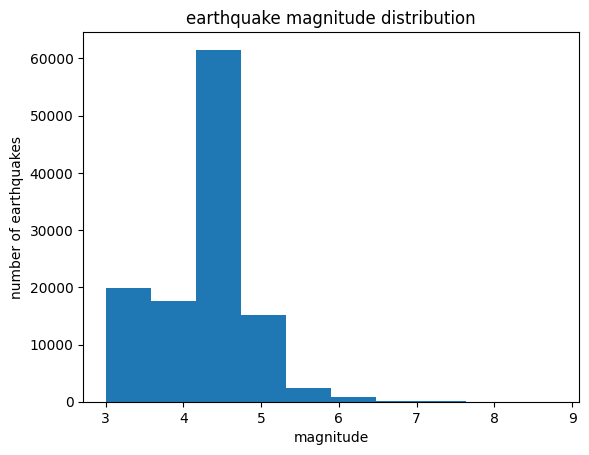

In [ ]:
import matplotlib.pyplot as plt

#Magnitude distribution
plt.hist(df['mag'], bins=10)
plt.xlabel('magnitude')
plt.ylabel('number of earthquakes')
plt.title('earthquake magnitude distribution')
plt.show()

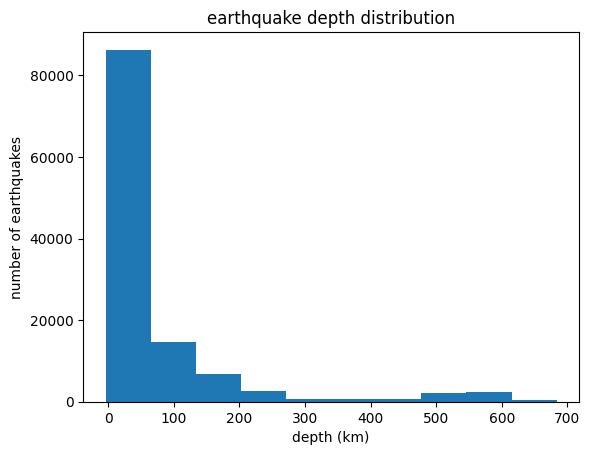

In [108]:
#Depth distribution
plt.hist(df['depth_km'], bins=10)
plt.xlabel('depth (km)')
plt.ylabel('number of earthquakes')
plt.title('earthquake depth distribution')
plt.show()

In [110]:
df['year'] = df['time'].dt.year
yearly_counts = df['year'].value_counts().sort_index()
yearly_counts

year
2021    21926
2022    20208
2023    20830
2024    18659
2025    22818
2026    13226
Name: count, dtype: int64

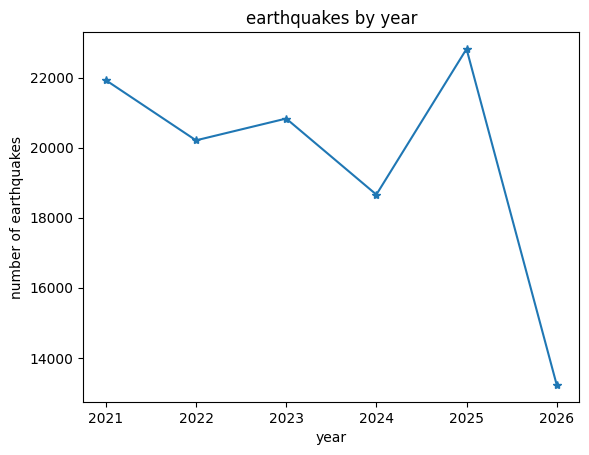

In [111]:
#Earthquakes by year
plt.plot(yearly_counts.index, yearly_counts.values, marker='*')
plt.xlabel('year')
plt.ylabel('number of earthquakes')
plt.title('earthquakes by year')
plt.show()

In [112]:
#Earthquakes by month
df["months"] = df['time'].dt.month_name()
month_order = ['January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']
monthly_counts = df['months'].value_counts().reindex(month_order)
monthly_counts

months
January      10579
February     10065
March        10931
April        10331
May           9763
June          9556
July         11696
August       10656
September     8316
October       8145
November      7954
December      9675
Name: count, dtype: int64

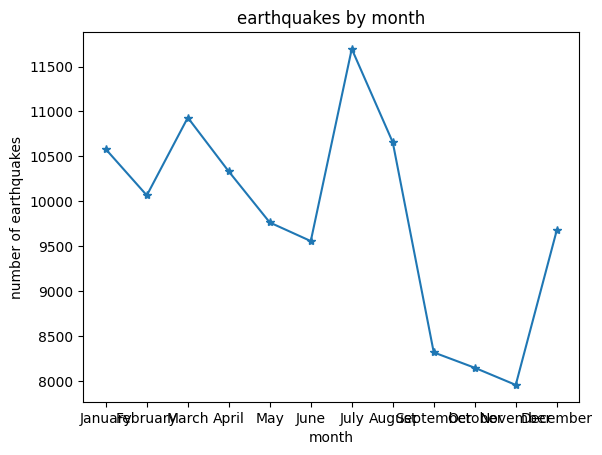

In [114]:
#Earthquakes by month 
plt.plot(monthly_counts.index, monthly_counts.values, marker= '*')
plt.xlabel ('month')
plt.ylabel('number of earthquakes')
plt.title('earthquakes by month')
plt.show()

In [ ]:
df_new.select_dtypes("object").columns

In [120]:
import streamlit as st